## **Algorithm : Linear SVM :**

### **Project : Breast Tumor Classification** 

#### **Problem Statement : Classify breast tumors as malignant or benign using medical measurements of cell nuclei.**

In [17]:
# Step No 1 : Import Required Libraries

# Import Numerical library
import numpy as np 

# import pandas library 
import pandas as pd 

# Import Plotting library 
import matplotlib.pyplot as plt 

# Import seaborn library 
import seaborn as sns 

# Import train test split 
from sklearn.model_selection import train_test_split

# Import Label Encoder 
from sklearn.preprocessing import LabelEncoder

# Import Standard Scaler 
from sklearn.preprocessing import StandardScaler

# import Support Vector Classifier 
from sklearn.svm import SVC

# Import Evaluation Metrics
from sklearn.metrics import (
    accuracy_score , 
    classification_report,
    confusion_matrix
)

In [18]:
# Step No 2 : Load Dataset 
df = pd.read_csv("Breast_Cancer_Classification_Dataset.csv")

In [19]:
# Step No 3 : Data Understanding 

# Display first 5 rows 
print("\nFirst 5 Rows : ")
print(df.head())

# Display dataset shape 
print("\nDataset Shape : ")
print(df.shape)

# Display column names 
print("\nColumn Names : ")
print(df.columns.tolist())

# Display dataset information
print("\nDataset Information : ")
df.info()

# Dsplay Statistical Summary 
print("\nStatistical Summary : ")
print(df.describe())


First 5 Rows : 
   PatientID  mean radius  ...  worst fractal dimension  Diagnosis
0          1        17.99  ...                  0.11890  Malignant
1          2        20.57  ...                  0.08902  Malignant
2          3        19.69  ...                  0.08758  Malignant
3          4        11.42  ...                  0.17300  Malignant
4          5        20.29  ...                  0.07678  Malignant

[5 rows x 32 columns]

Dataset Shape : 
(569, 32)

Column Names : 
['PatientID', 'mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst conca

In [20]:
# Step No 4 : Data Cleaning 

# Check Missing Values 
print("\nMissing Values : ")
print(df.isnull().sum())

# Check Duplicate Rows 
print("\nDuplicate Rows : ")
print(df.duplicated().sum())

# Remove duplicate rows 
df = df.drop_duplicates()

# Check Missing Values after cleaning 
print("\nMissing Values After Cleaning : ")
print(df.isnull().sum())


Missing Values : 
PatientID                  0
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
Diagnosis                  0
dtype: int64

Duplicate Rows : 
0

Missing Values Aft

In [21]:
# Step No 5 : Encode Target Variable 

# Create Label Encoder Object 
encoder = LabelEncoder()

# Convert Diagnosis into numerical values 
# Benign and Malignant will become 0 and 1 
df["Diagnosis"] = encoder.fit_transform(df["Diagnosis"])

# Display encoded target distribution 
print("\nEncoded Diagnosis Distribution : ")
print(df["Diagnosis"].value_counts())

# Display encoding mapping 
print("\nDiagnosis Encoding : ")
for label , value in zip(
    encoder.classes_,
    encoder.transform(encoder.classes_)
):
    
    print(label , "=" , value)


Encoded Diagnosis Distribution : 
Diagnosis
0    357
1    212
Name: count, dtype: int64

Diagnosis Encoding : 
Benign = 0
Malignant = 1


In [22]:
# Step No 6 : Define Features and Target 

# Define input features 
# PatientID is removed because it is only an identifier 
X = df.drop(
    columns=[
        "PatientID", 
        "Diagnosis"
    ]
)

# Define target variable 
y = df["Diagnosis"]

# Display feature shape 
print("\nFeature Shape : ")
print(X.shape)

# Display target shape 
print("\nTarget Shape : ")
print(y.shape)


Feature Shape : 
(569, 30)

Target Shape : 
(569,)


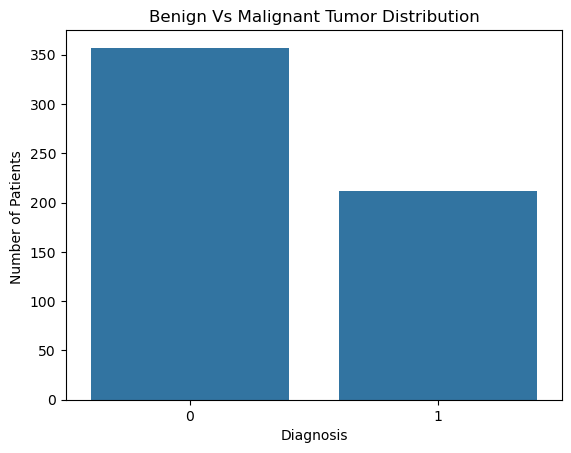

In [23]:
# Step No 7 : Target Visualization 

# Create Count Plot 
sns.countplot(x = "Diagnosis" , data = df)

# Set Plot title 
plt.title("Benign Vs Malignant Tumor Distribution")

# Set x-axis label 
plt.xlabel("Diagnosis")

# Set y-axis label 
plt.ylabel("Number of Patients ")

# Display Plot 
plt.show()

In [24]:
# Step No 8 : Train Test Split 
# Split dataset into training and testing data 
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size= 0.20,
    random_state=42,
    stratify=y
)

# Display training and testing shapes 
print("\nTraining Feature Shape : ")
print(X_train.shape)

print("\nTesting Feature Shape : ")
print(X_test.shape)

print("\nTraining Target Shape : ")
print(y_train.shape)

print("\nTesting Target Shape : ")
print(y_test.shape)


Training Feature Shape : 
(455, 30)

Testing Feature Shape : 
(114, 30)

Training Target Shape : 
(455,)

Testing Target Shape : 
(114,)


In [25]:
# Step No 9 : Feature Scaling 

# Create StandardScaler Object 
scaler = StandardScaler()

# Fit scaler on training data
# and transform training data 
X_train_scaled = scaler.fit_transform(X_train)

# Transform testing data 
# using scaler learned from training data 
X_test_scaled = scaler.transform(X_test)

In [26]:
# Step No 10 : Create Linear SVM Model 
# Create Linear SVM Classifier 
model = SVC(
    kernel="linear",
    C = 1.0 , 
    random_state=42
)

# Display Model 
print("\nModel : ")
print(model)


Model : 
SVC(kernel='linear', random_state=42)


In [27]:
# Step No 11 : Train Linear SVM Model 
# Train the model using scaled training data 
model.fit(
    X_train_scaled , 
    y_train
)

# Display training completion
print("\nLinear SVM Model Training Completed .")


Linear SVM Model Training Completed .


In [28]:
# Step No 12 : Make Predictions 
# Predict tumor class for test data 
y_pred = model.predict(
    X_test_scaled
)

# Display Predicted Values
print("\nPredicted Values : ")
print(y_pred)


Predicted Values : 
[0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 0 0
 0 1 0 0 0 1 0 0 1 0 1 0 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0 1 1 0
 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0
 0 0 1]


In [29]:
# Step No 13 : Model Evaluation 
#Calculate accuracy 
accuracy = accuracy_score(
    y_test , 
    y_pred 
)

# Display accuracy 
print("\nAccuracy Score : ")
print(accuracy)

# Display accuracy in percentage 
print("\nAccuracy Percentage : ")
print(
    round(
        accuracy * 100 , 
        2
    ),
    "%"
)

# Classification Report 
# Display Precision , recall , and F1-score 
print("\nClassification Report : ")

print(classification_report(
    y_test , 
    y_pred,
    target_names=encoder.classes_
))

# Calculate Confusion Matrix 
cm = confusion_matrix(
    y_test , 
    y_pred
)

# Display confusion matrix 
print("\nConfusion Matrix : ")
print(cm)


Accuracy Score : 
0.9649122807017544

Accuracy Percentage : 
96.49 %

Classification Report : 
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114


Confusion Matrix : 
[[72  0]
 [ 4 38]]


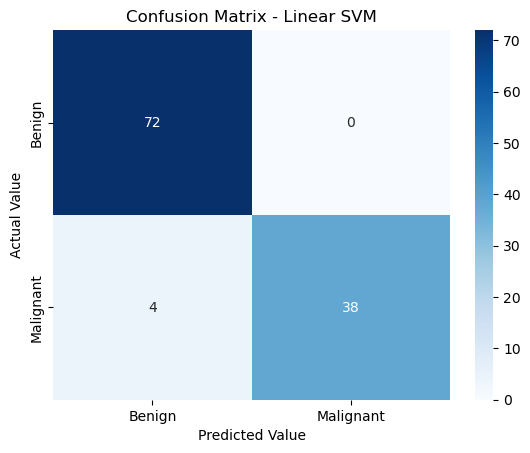

In [30]:
# Step No 14 : Confusion Matrix Visualization 
# Create Heatmap 
sns.heatmap(
    cm,
    annot=True,
    fmt = "d",
    cmap = "Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

# Set Plot Title 
plt.title("Confusion Matrix - Linear SVM")

# Set x-axis label 
plt.xlabel("Predicted Value")

# Set y-axis label 
plt.ylabel("Actual Value")

# Display Plot 
plt.show()

In [31]:
# Step No 15 : Final Model Performance 
# Display final model accuracy 
print("\n================================")
print("       LINEAR SVM PERFORMANCE ")
print("==================================")

print(
    "Accuracy : ",
    round(accuracy * 100 , 2
          ),
    "%"
          
)

print("==================================")


       LINEAR SVM PERFORMANCE 
Accuracy :  96.49 %


In [32]:
# Step No 16 : User Input Prediction
# Ask user whether they want to test a new patient 
choice = input("\nDo you want to predict a new patient ? (yes/no) : ")

# Check user choice 
if choice.lower() == "yes":
    print(
        "\nEnter Values for all medical features."
    )
    
    # Create empty list for user input
    user_values = []
    
    # Loop through every feature
    for feature in X.columns:
        
        # Take feature value from user 
        value = float(input(
            f"Enter {feature} : "
        ))
        
        # Store Value 
        user_values.append(value)
    
    # Create DataFrame using user values 
    user_data = pd.DataFrame(
        [user_values],
        columns=X.columns
    )
    
    # Scale user data 
    # Use the same scaler trained on training data 
    user_data_scaled = scaler.transform(
        user_data
    )
    
    # Predict tumor class
    user_prediction = model.predict(
        user_data_scaled
    )
    
    # Convert numerical prediction 
    # back to original class name 
    predicted_class = encoder.inverse_transform(
        user_prediction
    )[0]
    
    # Display final prediction 
    print("\n============================")
    print("         TUMOR PREDICTION")
    print("==============================")
    
    print(
        "Predicted Diagnosis : ",
        predicted_class
    )
    
    print("===============================")